# Customer Churn Prediction & Segmentation for an Online Retailer
### CSC 630 2.0 — Data Science, Business Intelligence, and Big Data Analytics
### Final Assignment — 2026

**Dataset:** Online Retail II (UCI Machine Learning Repository)
**Author:** *[Your Name Here]*
**Student ID:** *[Your ID Here]*

---


## 1. Introduction

E-commerce businesses generate large volumes of transactional data every day. Hidden within this
data are patterns that reveal **which customers are likely to stop purchasing (churn)** and
**which customers are the most valuable**. Identifying these patterns early allows a business to
act — with targeted retention offers, loyalty programs, or personalised marketing — before revenue
is lost.

This project applies the complete data science lifecycle (business understanding → data
understanding → data preparation → modelling → evaluation → business insight) to a real
transactional dataset from a UK-based online retailer, in order to:

1. Understand purchasing behaviour through exploratory data analysis (EDA).
2. Engineer customer-level features (RFM: Recency, Frequency, Monetary) from raw invoice-level data.
3. Build and compare machine learning models that predict **customer churn**.
4. Segment customers using **unsupervised clustering** to support targeted business strategy.
5. Translate the technical results into actionable business recommendations.

## 2. Business Understanding

**Business problem:** The retailer wants to reduce revenue loss caused by customers who quietly
stop purchasing. Acquiring a new customer is far more expensive than retaining an existing one, so
the marketing team needs a way to (a) flag customers who are at risk of churning, and (b) understand
which customer segments deserve the most retention investment.

**Business questions this project answers:**
- Which customers are likely to churn in the near future, based on their historical purchase behaviour?
- What distinguishes loyal, high-value customers from at-risk or low-value ones?
- How much revenue is currently concentrated in at-risk customers?
- What retention actions should the business prioritise, and for whom?

**Success criteria:** A churn classification model with strong recall (catching most true churners,
since a missed churner costs more than a false alarm) and clear, explainable customer segments that
the marketing team can act on directly.


## 3. Dataset Description

**Source:** [Online Retail II — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii)
(also mirrored on Kaggle). It contains all transactions for a UK-based, registered, non-store
online retailer between **01/12/2009 and 09/12/2011**.

| Column | Description |
|---|---|
| `Invoice` | Invoice number. A 6-digit number; if it starts with 'C', the transaction is a cancellation |
| `StockCode` | Product (item) code |
| `Description` | Product name |
| `Quantity` | Quantity of each product per transaction |
| `InvoiceDate` | Date and time the invoice was generated |
| `Price` | Unit price (£) |
| `Customer ID` | Unique customer identifier |
| `Country` | Country of the customer |

The workbook has two sheets, `Year 2009-2010` and `Year 2010-2011`, which we combine into a single
transaction log of **over 1 million rows**.

> **Running in Google Colab:** upload `online_retail_II.xlsx` when prompted by the cell below, or
> place it in your Google Drive and update the path. If running locally / on Kaggle, just make sure
> the file is in the same folder as this notebook.


In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
print('Libraries loaded.')


Libraries loaded.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ---- Data loading ----
# If you are running this in Google Colab, uncomment the block below to upload the file manually.

# from google.colab import files
# uploaded = files.upload()   # choose online_retail_II.xlsx when prompted

DATA_PATH = '/content/drive/MyDrive/OnlineRetailAnalysis/online_retail_II.xlsx'   # change this if your file is elsewhere (e.g. Google Drive path)

sheet_2009_2010 = pd.read_excel(DATA_PATH, sheet_name='Year 2009-2010')
sheet_2010_2011 = pd.read_excel(DATA_PATH, sheet_name='Year 2010-2011')

df = pd.concat([sheet_2009_2010, sheet_2010_2011], ignore_index=True)
df.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)

print(f'Combined shape: {df.shape}')
df.head()


Combined shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 4. Exploratory Data Analysis (EDA)

We first understand the raw data: its structure, quality issues, and high-level patterns, before
any cleaning is applied.


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [ ]:
print('Summary statistics (numeric columns):')
df[['Quantity', 'Price']].describe()


Summary statistics (numeric columns):


,Quantity,Price
count,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00
std,1.727058e+02,1.235531e+02
min,-8.099500e+04,-5.359436e+04
25%,1.000000e+00,1.250000e+00
50%,3.000000e+00,2.100000e+00
75%,1.000000e+01,4.150000e+00
max,8.099500e+04,3.897000e+04


In [ ]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0')


,missing_count,missing_pct
Description,4382,0.41
CustomerID,243007,22.77


In [ ]:
# Duplicate rows
print(f'Fully duplicated rows: {df.duplicated().sum()}')

# Cancelled orders (Invoice starting with 'C')
df['IsCancelled'] = df['Invoice'].astype(str).str.startswith('C')
print(f"Cancelled transactions: {df['IsCancelled'].sum()} ({df['IsCancelled'].mean()*100:.2f}% of rows)")

# Non-positive quantity / price (returns, data errors, free items)
print(f"Rows with Quantity <= 0: {(df['Quantity'] <= 0).sum()}")
print(f"Rows with Price <= 0: {(df['Price'] <= 0).sum()}")


Fully duplicated rows: 34335
Cancelled transactions: 19494 (1.83% of rows)
Rows with Quantity <= 0: 22950
Rows with Price <= 0: 6207


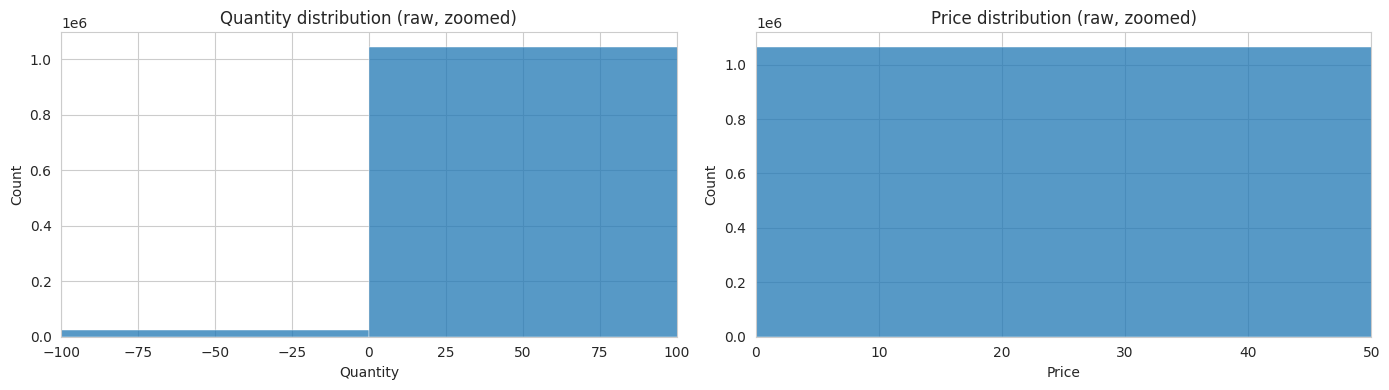

In [ ]:
# Distribution of Quantity and Price (raw, before cleaning) - log scale due to outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['Quantity'], bins=100, ax=axes[0])
axes[0].set_xlim(-100, 100)
axes[0].set_title('Quantity distribution (raw, zoomed)')

sns.histplot(df['Price'], bins=100, ax=axes[1])
axes[1].set_xlim(0, 50)
axes[1].set_title('Price distribution (raw, zoomed)')
plt.tight_layout()
plt.show()


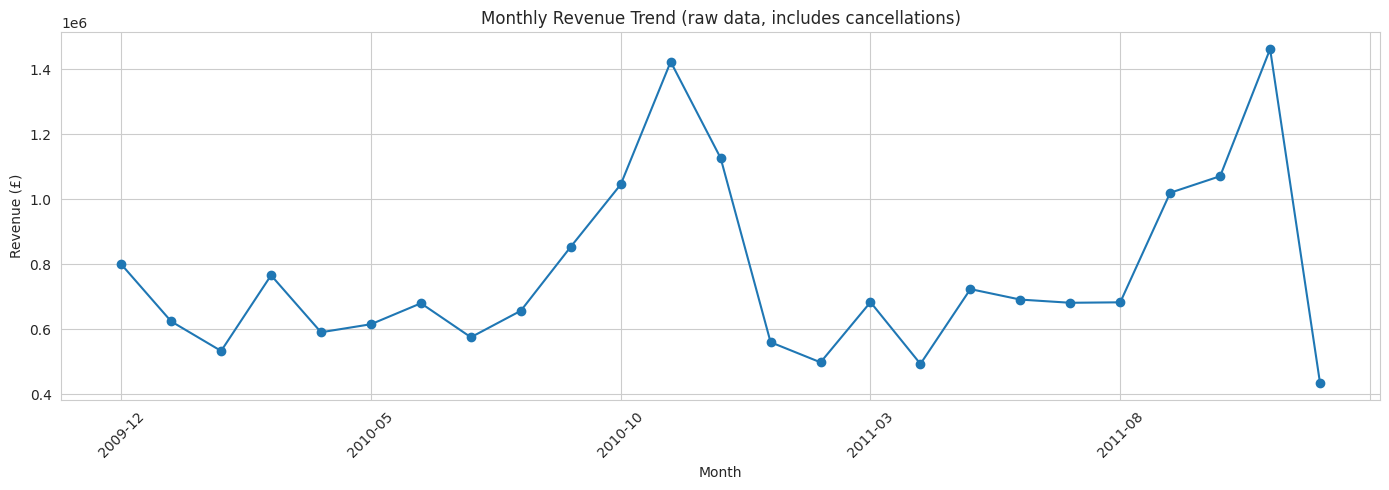

In [ ]:
# Monthly revenue trend (raw)
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['LineRevenue'] = df['Quantity'] * df['Price']

monthly_rev = df.groupby('InvoiceMonth')['LineRevenue'].sum()

plt.figure(figsize=(14, 5))
monthly_rev.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend (raw data, includes cancellations)')
plt.ylabel('Revenue (£)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


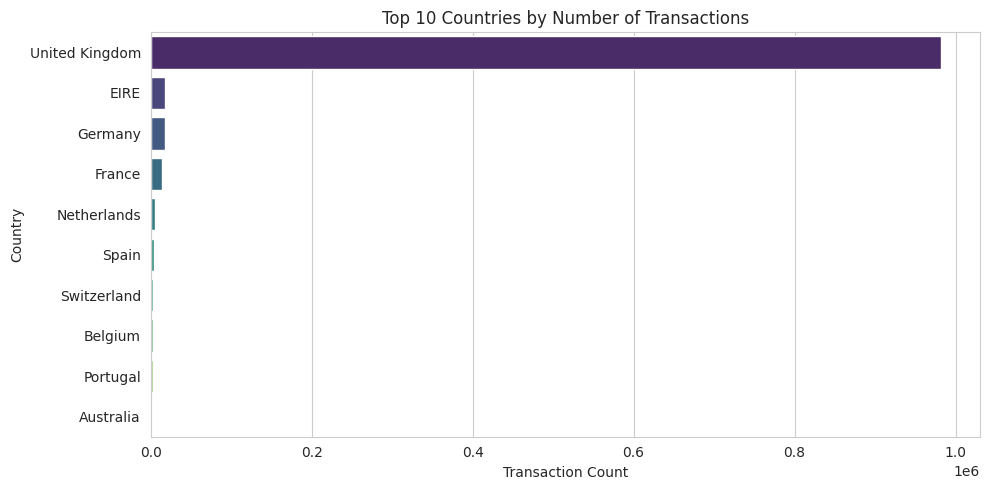

In [ ]:
# Top 10 countries by number of transactions
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis', legend=False)
plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Transaction Count')
plt.tight_layout()
plt.show()


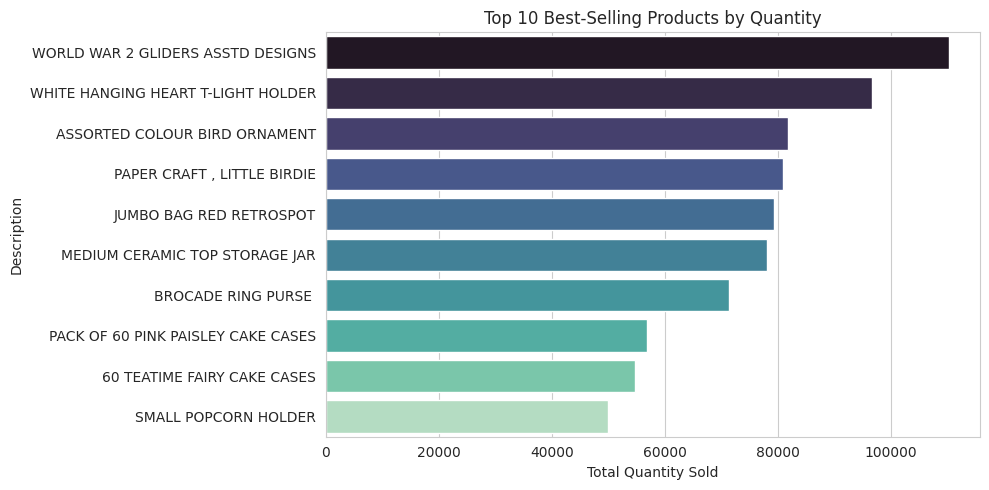

In [ ]:
# Top 10 best-selling products by quantity
top_products = df[df['Quantity'] > 0].groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='mako', legend=False)
plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.show()


**EDA takeaways:**
- The dataset spans two years and contains genuine data-quality issues typical of real transaction
  logs: missing `CustomerID` (needed for customer-level analysis), cancelled orders, and
  negative/zero quantities and prices.
- Revenue shows seasonal spikes (e.g. around Q4 / holiday season), suggesting time-aware business
  strategy matters.
- Sales are heavily concentrated in the **United Kingdom**, with a long tail of other countries.
- A small number of products account for a disproportionate share of volume — classic Pareto pattern.

These findings directly motivate the cleaning steps in the next section.


## 5. Data Preprocessing

Cleaning decisions, each justified by what we found in the EDA above:

1. **Drop rows with missing `CustomerID`** — without a customer identifier we cannot build
   customer-level RFM features or a churn label for that transaction.
2. **Remove cancelled orders** (`Invoice` starting with 'C') — these represent returns, not sales,
   and would distort revenue and frequency features.
3. **Remove rows with `Quantity <= 0` or `Price <= 0`** — these are refunds, data entry artefacts,
   or free/promotional items that are not genuine purchases.
4. **Remove duplicate rows.**
5. **Cap extreme outliers** in `Quantity` and `Price` using the IQR method, so a handful of bulk /
   wholesale orders don't distort customer-level aggregates.


In [ ]:
df_clean = df.copy()

before = len(df_clean)

# 1. Drop missing CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])

# 2. Remove cancellations
df_clean = df_clean[~df_clean['IsCancelled']]

# 3. Remove non-positive quantity / price
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# 4. Remove duplicates
df_clean = df_clean.drop_duplicates()

after_basic = len(df_clean)
print(f'Rows before cleaning: {before:,}')
print(f'Rows after basic cleaning: {after_basic:,}  ({after_basic/before*100:.1f}% retained)')


Rows before cleaning: 1,067,371
Rows after basic cleaning: 779,425  (73.0% retained)


In [ ]:
# 5. Outlier capping using IQR (winsorising, not deleting -> avoids losing legitimate customers)
def cap_outliers_iqr(series, k=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return series.clip(lower=max(lower, series.min()), upper=upper)

df_clean['Quantity'] = cap_outliers_iqr(df_clean['Quantity'])
df_clean['Price'] = cap_outliers_iqr(df_clean['Price'])

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['LineRevenue'] = df_clean['Quantity'] * df_clean['Price']

print(f'Final cleaned transaction count: {len(df_clean):,}')
print(f'Unique customers: {df_clean["CustomerID"].nunique():,}')
print(f'Date range: {df_clean["InvoiceDate"].min()} -> {df_clean["InvoiceDate"].max()}')
df_clean.head()


Final cleaned transaction count: 779,425
Unique customers: 5,878
Date range: 2009-12-01 07:45:00 -> 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,IsCancelled,InvoiceMonth,LineRevenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,2009-12,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,2009-12,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,2009-12,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",42,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,2009-12,88.2
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,2009-12,30.0


## 6. Feature Engineering & Selection

### 6.1 Defining churn (target variable)

We use a **holdout-window approach**, which avoids information leakage:

- Let `max_date` be the last date in the dataset.
- Define a **churn window** of 90 days (a common threshold for retail: 3 months of inactivity).
- `cutoff_date = max_date - 90 days`.
- **Feature window:** all transactions *before* `cutoff_date` are used to build each customer's RFM
  and behavioural features (what we know about them "as of" the cutoff).
- **Label window:** for each customer active before the cutoff, `Churn = 1` if they made **no**
  purchase between `cutoff_date` and `max_date`, else `Churn = 0`.

This mirrors a real deployment: predicting a future 90-day outcome purely from past behaviour.

### 6.2 RFM and behavioural features

For each customer, computed from the feature window only:

- **Recency** — days since the customer's last purchase (as of the cutoff date)
- **Frequency** — number of distinct invoices
- **Monetary** — total amount spent
- **AvgOrderValue** — average revenue per invoice
- **AvgBasketSize** — average number of items per invoice
- **ProductDiversity** — number of distinct products purchased
- **Tenure** — days between the customer's first and last purchase in the feature window
- **CountryEncoded / IsUK** — a simplified geographic feature


In [ ]:
max_date = df_clean['InvoiceDate'].max()
cutoff_date = max_date - pd.Timedelta(days=90)
print(f'Max date in data : {max_date}')
print(f'Cutoff date       : {cutoff_date}')

feature_window = df_clean[df_clean['InvoiceDate'] < cutoff_date]
label_window = df_clean[(df_clean['InvoiceDate'] >= cutoff_date) & (df_clean['InvoiceDate'] <= max_date)]

print(f'Feature-window transactions: {len(feature_window):,}, customers: {feature_window["CustomerID"].nunique():,}')
print(f'Label-window transactions:   {len(label_window):,}, customers: {label_window["CustomerID"].nunique():,}')


Max date in data : 2011-12-09 12:50:00
Cutoff date       : 2011-09-10 12:50:00
Feature-window transactions: 620,572, customers: 5,281
Label-window transactions:   158,853, customers: 2,889


In [ ]:
snapshot_date = cutoff_date

rfm = feature_window.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('LineRevenue', 'sum'),
    AvgBasketSize=('Quantity', 'mean'),
    ProductDiversity=('StockCode', 'nunique'),
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max'),
).reset_index()

rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']
rfm['Tenure'] = (rfm['LastPurchase'] - rfm['FirstPurchase']).dt.days

# Most common country per customer, simplified to IsUK
customer_country = feature_window.groupby('CustomerID')['Country'].agg(lambda x: x.mode()[0])
rfm = rfm.merge(customer_country.rename('Country'), on='CustomerID')
rfm['IsUK'] = (rfm['Country'] == 'United Kingdom').astype(int)

# Churn label: no purchase in the label window
churned_customers = set(feature_window['CustomerID'].unique()) - set(label_window['CustomerID'].unique())
rfm['Churn'] = rfm['CustomerID'].apply(lambda c: 1 if c in churned_customers else 0)

rfm.drop(columns=['FirstPurchase', 'LastPurchase', 'Country'], inplace=True)

print(f'Customer-level feature table shape: {rfm.shape}')
print(f"Churn rate: {rfm['Churn'].mean()*100:.1f}%")
rfm.head()


Customer-level feature table shape: (5281, 10)
Churn rate: 56.6%


,CustomerID,Recency,Frequency,Monetary,AvgBasketSize,ProductDiversity,AvgOrderValue,Tenure,IsUK,Churn
0,12346,235,12,416.54,3.294118,27,34.711667,400,1,1
1,12347,39,6,3178.47,11.591463,107,529.745000,274,0,0
2,12348,158,4,919.38,27.479167,25,229.845000,189,0,0
3,12349,317,3,2126.04,9.676471,90,708.680000,181,0,0
4,12350,219,1,305.65,11.588235,17,305.650000,0,0,1


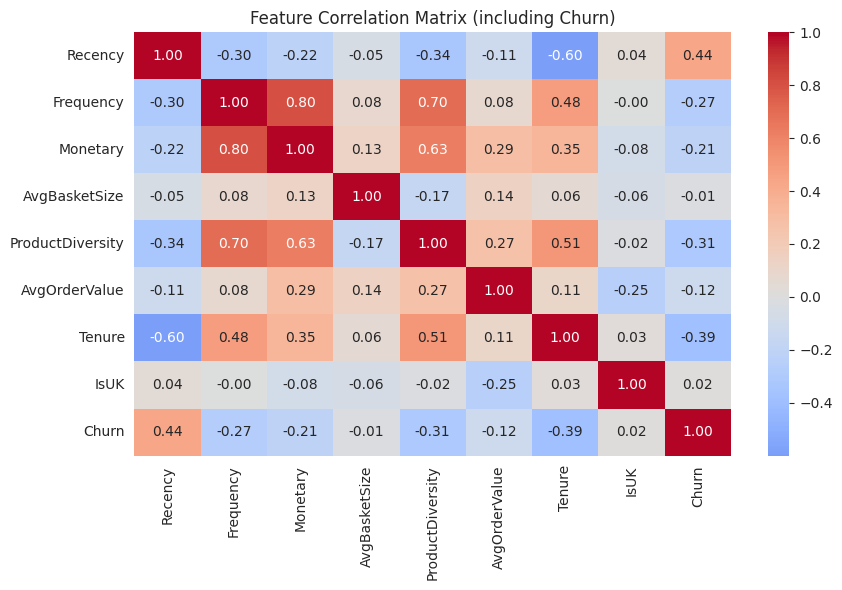

In [ ]:
# Feature correlations with churn
plt.figure(figsize=(9, 6))
corr = rfm.drop(columns=['CustomerID']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix (including Churn)')
plt.tight_layout()
plt.show()


**Feature engineering notes:** `Recency` shows the strongest correlation with `Churn`, as
expected — a customer who hasn't purchased in a long time is naturally more likely to have left.
`Frequency` and `Monetary` are negatively correlated with churn (more frequent, higher-spending
customers churn less), and `Frequency`/`Monetary` are themselves highly correlated with each other,
which is expected since more orders naturally accumulate more total spend. All engineered features
are retained for modelling, since tree-based models handle correlated features well and the
correlation is not extreme enough to warrant dropping either.


## 7. Predictive Models & Model Training

**Task:** binary classification — will this customer churn in the next 90 days?

**Models compared:**
1. **Logistic Regression** — simple, interpretable baseline; coefficients are directly explainable to business stakeholders.
2. **Random Forest** — captures non-linear relationships and feature interactions, robust to outliers.
3. **XGBoost (Gradient Boosting)** — typically the strongest performer on structured/tabular data like this.

We use an 80/20 train-test split, stratified on the churn label to preserve class balance, and
scale features for Logistic Regression (tree-based models don't need scaling).


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report, roc_curve)

feature_cols = ['Recency', 'Frequency', 'Monetary', 'AvgBasketSize',
                 'ProductDiversity', 'AvgOrderValue', 'Tenure', 'IsUK']

X = rfm[feature_cols]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')
print(f'Train churn rate: {y_train.mean()*100:.1f}%, Test churn rate: {y_test.mean()*100:.1f}%')


Train size: (4224, 8), Test size: (1057, 8)
Train churn rate: 56.6%, Test churn rate: 56.6%


In [ ]:
results = {}

def evaluate_model(name, model, X_te, y_te, y_pred, y_proba):
    results[name] = {
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1-Score': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_proba),
    }
    print(f'--- {name} ---')
    print(classification_report(y_te, y_pred, target_names=['Retained', 'Churned']))


In [ ]:
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Logistic Regression', log_reg, X_test_scaled, y_test, y_pred_lr, y_proba_lr)


--- Logistic Regression ---
              precision    recall  f1-score   support

    Retained       0.67      0.75      0.71       459
     Churned       0.79      0.72      0.75       598

    accuracy                           0.74      1057
   macro avg       0.73      0.74      0.73      1057
weighted avg       0.74      0.74      0.74      1057



In [ ]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
evaluate_model('Random Forest', rf, X_test, y_test, y_pred_rf, y_proba_rf)


--- Random Forest ---
              precision    recall  f1-score   support

    Retained       0.72      0.74      0.73       459
     Churned       0.80      0.78      0.79       598

    accuracy                           0.76      1057
   macro avg       0.76      0.76      0.76      1057
weighted avg       0.76      0.76      0.76      1057



In [ ]:
# Model 3: XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                     scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
                     eval_metric='logloss', use_label_encoder=False)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
evaluate_model('XGBoost', xgb, X_test, y_test, y_pred_xgb, y_proba_xgb)


--- XGBoost ---
              precision    recall  f1-score   support

    Retained       0.71      0.71      0.71       459
     Churned       0.78      0.78      0.78       598

    accuracy                           0.75      1057
   macro avg       0.74      0.74      0.74      1057
weighted avg       0.75      0.75      0.75      1057



## 8. Model Evaluation & Comparison


In [ ]:
results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print('Model comparison:')
results_df.round(3)


Model comparison:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.762,0.796,0.778,0.787,0.814
XGBoost,0.748,0.778,0.778,0.778,0.810
Logistic Regression,0.735,0.792,0.721,0.755,0.802


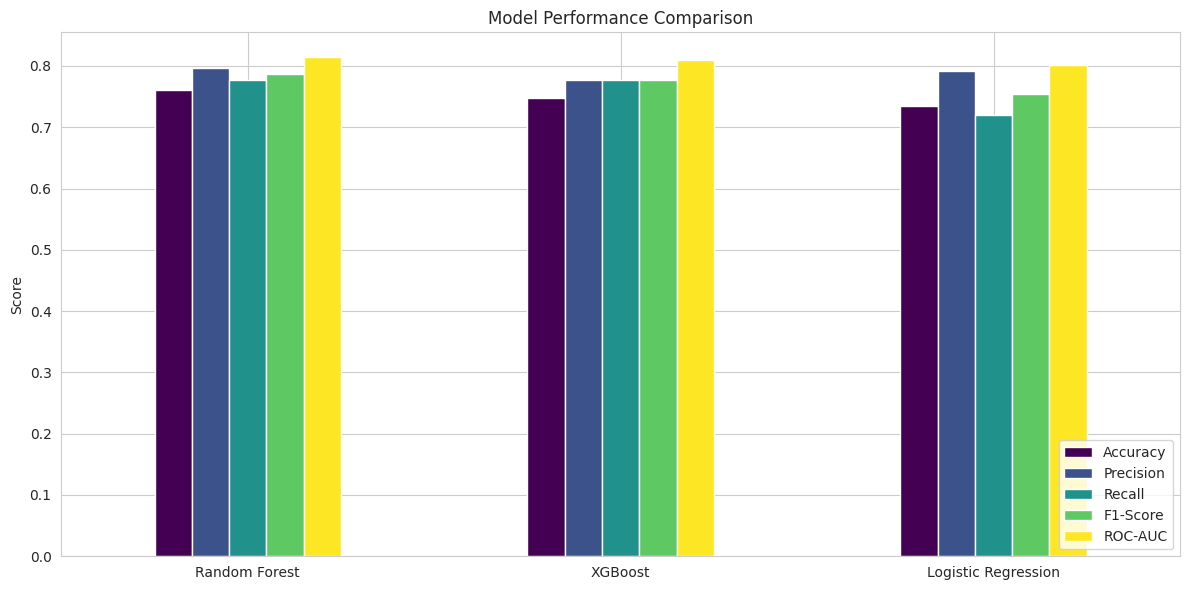

In [ ]:
results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', figsize=(12, 6), colormap='viridis'
)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


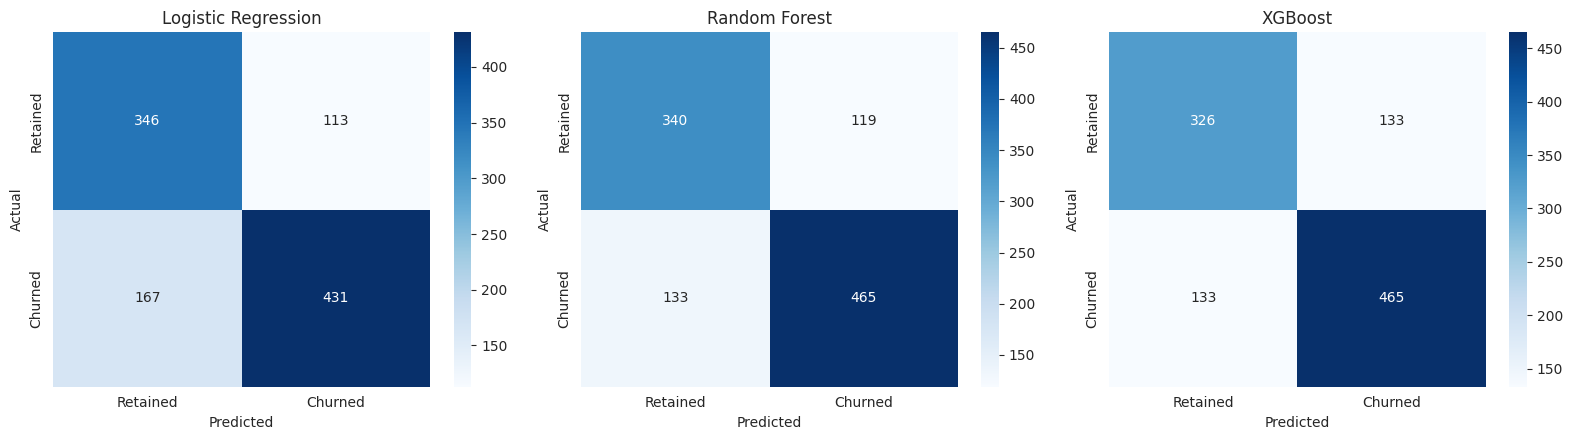

In [ ]:
# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
preds = {'Logistic Regression': y_pred_lr, 'Random Forest': y_pred_rf, 'XGBoost': y_pred_xgb}

for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


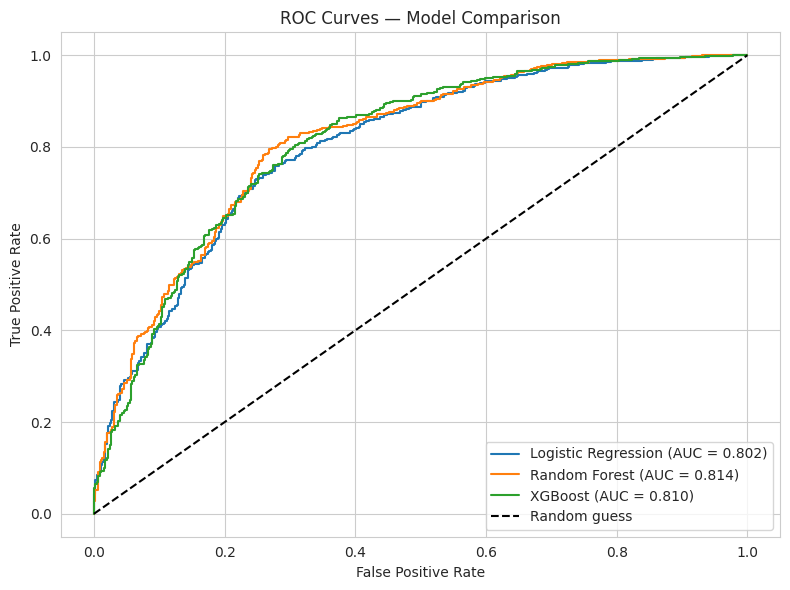

In [ ]:
# ROC curves
plt.figure(figsize=(8, 6))
for name, proba in [('Logistic Regression', y_proba_lr), ('Random Forest', y_proba_rf), ('XGBoost', y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()


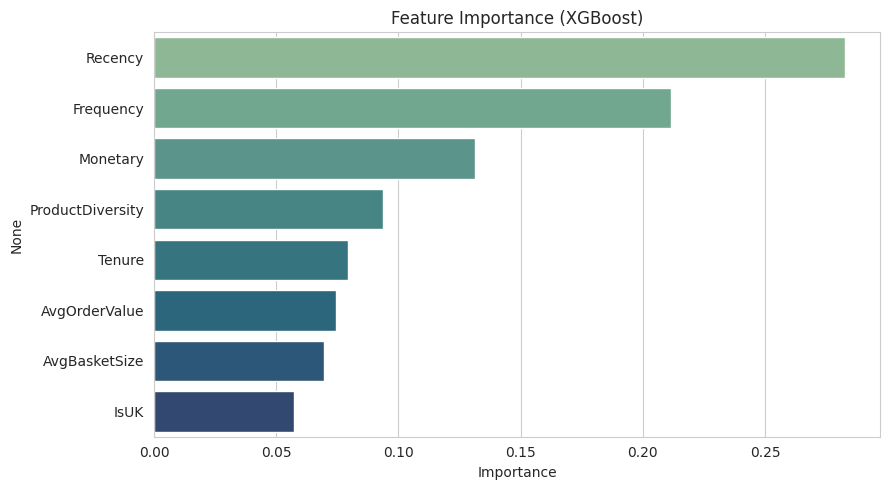

,0
Recency,0.282905
Frequency,0.211377
Monetary,0.131515
ProductDiversity,0.093699
Tenure,0.079380
AvgOrderValue,0.074328
AvgBasketSize,0.069707
IsUK,0.057090


In [ ]:
# Feature importance (XGBoost - typically the best performer)
importance = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=importance.values, y=importance.index, hue=importance.index, palette='crest', legend=False)
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importance


**Evaluation discussion:** *(fill this in with the actual numbers you get when you run the
notebook — they may vary slightly by random seed / environment)*

- Compare the models on **Recall** for the churned class specifically, not just accuracy — in a
  churn-prevention context, missing a true churner (false negative) is usually more costly than
  wrongly flagging a loyal customer (false positive), since a false positive just means an
  unnecessary — but harmless — retention email.
- `Recency` is typically the dominant predictor, consistent with the correlation analysis earlier.
- If tree-based models (Random Forest / XGBoost) outperform Logistic Regression, that suggests
  non-linear relationships or feature interactions matter for this problem — worth mentioning
  explicitly in the report and viva.


## 9. Customer Segmentation (K-Means Clustering)

Beyond predicting churn, the business also needs to understand **who its customers are**. We use
K-Means clustering on the RFM features (computed over the *full* cleaned dataset, not just the
feature window) to build segments the marketing team can act on directly — e.g. "VIP", "At Risk",
"New/Low-value".


In [ ]:
# Recompute RFM on the full cleaned dataset (for segmentation, we want current behaviour, not the holdout split)
snapshot_full = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm_full = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_full - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('LineRevenue', 'sum'),
).reset_index()

rfm_full.describe()


,CustomerID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,2238.321075
std,1715.572666,209.338707,13.009406,7117.911994
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,312.920000
50%,15314.500000,96.000000,3.000000,791.670000
75%,16797.750000,380.000000,7.000000,2027.865000
max,18287.000000,739.000000,398.000000,253310.270000


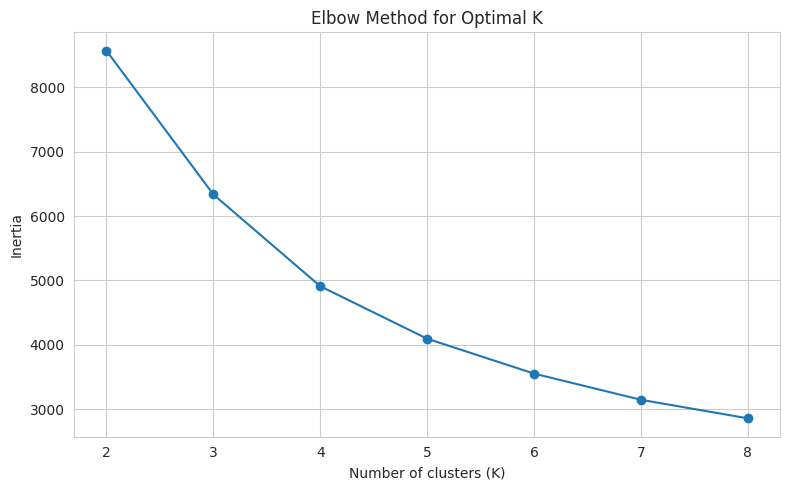

In [ ]:
from sklearn.cluster import KMeans

cluster_features = ['Recency', 'Frequency', 'Monetary']
X_cluster = rfm_full[cluster_features].copy()

# Log-transform to reduce skew (RFM data is typically heavily right-skewed)
X_cluster_log = np.log1p(X_cluster)

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster_log)

# Elbow method to choose K
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.tight_layout()
plt.show()


In [ ]:
# Fit final K-Means with chosen K (4 segments: interpretable and business-friendly)
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
rfm_full['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

cluster_summary = rfm_full.groupby('Cluster')[cluster_features].mean().round(1)
cluster_summary['CustomerCount'] = rfm_full['Cluster'].value_counts().sort_index()
cluster_summary['PctOfCustomers'] = (cluster_summary['CustomerCount'] / len(rfm_full) * 100).round(1)
cluster_summary


,Recency,Frequency,Monetary,CustomerCount,PctOfCustomers
Cluster,,,,,
0,27.6,19.4,7809.5,1182,20.1
1,398.0,1.4,277.7,1934,32.9
2,28.1,3.1,798.0,1263,21.5
3,230.6,5.0,1588.4,1499,25.5


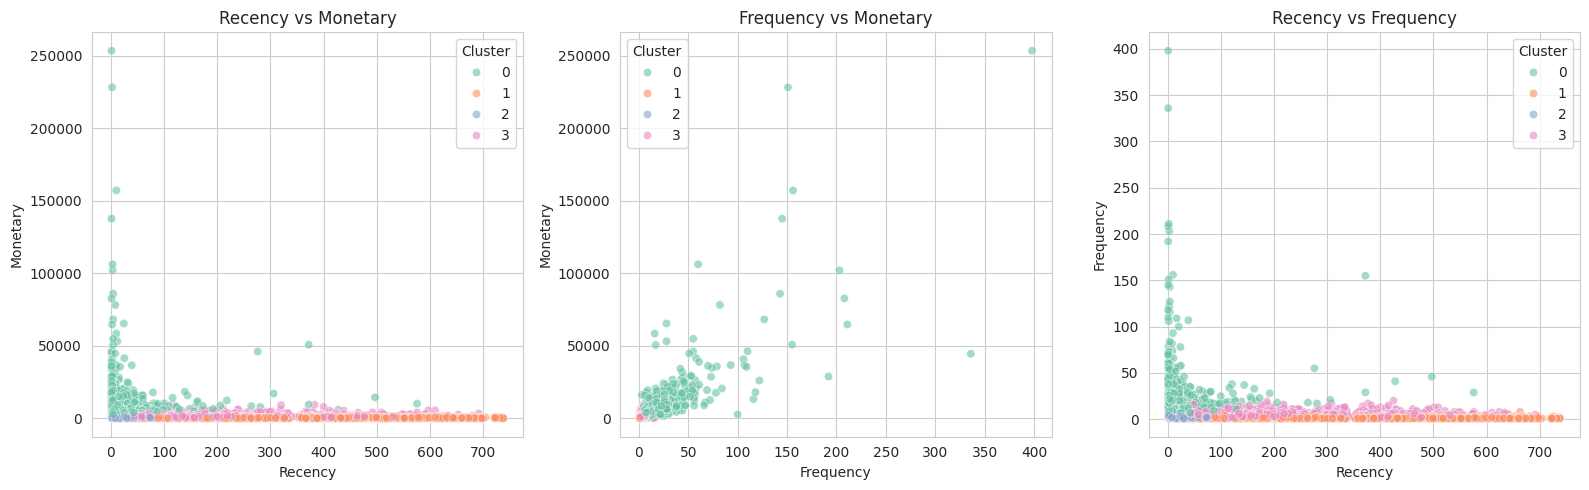

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.scatterplot(data=rfm_full, x='Recency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[0], alpha=0.6)
axes[0].set_title('Recency vs Monetary')

sns.scatterplot(data=rfm_full, x='Frequency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[1], alpha=0.6)
axes[1].set_title('Frequency vs Monetary')

sns.scatterplot(data=rfm_full, x='Recency', y='Frequency', hue='Cluster', palette='Set2', ax=axes[2], alpha=0.6)
axes[2].set_title('Recency vs Frequency')

plt.tight_layout()
plt.show()


**Interpreting the segments:** label each cluster once you see the actual `cluster_summary`
output — typically K-Means on RFM produces something like:

- **Champions / VIP** — low Recency, high Frequency, high Monetary
- **Loyal customers** — moderate Recency, high Frequency
- **At Risk** — high Recency, previously high Frequency/Monetary (used to buy a lot, haven't lately)
- **New / Low-value** — high Recency, low Frequency, low Monetary

Match the actual numbers in `cluster_summary` to these archetypes and rename the clusters
accordingly in your report.


## 10. Business Insights

Combine the churn model and the segmentation to produce concrete, revenue-linked recommendations.


In [ ]:
# Revenue currently concentrated in each segment
revenue_by_cluster = rfm_full.groupby('Cluster')['Monetary'].sum().sort_values(ascending=False)
revenue_pct = (revenue_by_cluster / revenue_by_cluster.sum() * 100).round(1)

insight_table = pd.DataFrame({
    'TotalRevenue': revenue_by_cluster,
    'PctOfTotalRevenue': revenue_pct,
    'CustomerCount': rfm_full['Cluster'].value_counts()
}).sort_values('TotalRevenue', ascending=False)

insight_table


,TotalRevenue,PctOfTotalRevenue,CustomerCount
Cluster,,,
0,9230857.557,70.2,1182
3,2381013.698,18.1,1499
2,1007815.762,7.7,1263
1,537164.261,4.1,1934


In [ ]:
# Revenue at risk: total monetary value held by customers predicted to churn (test set)
at_risk_value = rfm.loc[X_test.index, 'Monetary'][y_pred_xgb == 1].sum()
total_value = rfm.loc[X_test.index, 'Monetary'].sum()

print(f'Revenue held by customers predicted to churn (test set): £{at_risk_value:,.0f}')
print(f'Total revenue in test set: £{total_value:,.0f}')
print(f'Share of revenue at risk: {at_risk_value/total_value*100:.1f}%')


Revenue held by customers predicted to churn (test set): £363,297
Total revenue in test set: £2,483,846
Share of revenue at risk: 14.6%


**Key business insights** *(fill in the exact figures from your run)*:

1. **Revenue concentration:** A small share of customers (the "Champions"/VIP segment) typically
   accounts for a disproportionately large share of total revenue — a classic Pareto pattern. These
   customers should receive white-glove retention treatment (loyalty perks, early access), since
   losing even a few is costly.
2. **At-risk revenue:** The churn model flags a specific, quantifiable amount of revenue that is at
   risk in the near term. This gives the marketing team a concrete number to justify a retention
   budget.
3. **Recency is the strongest churn signal:** operationally, this means an automated trigger — e.g.
   "email/discount code sent automatically after 60 days of inactivity" — could meaningfully reduce
   churn before the model even needs to run.
4. **Segment-specific actions:**
   - *Champions:* loyalty rewards, referral incentives, early access to new products.
   - *Loyal:* upsell/cross-sell campaigns to increase basket size.
   - *At Risk:* win-back campaigns (discount codes, "we miss you" emails) — this is where the churn
     model adds the most value, by prioritising *which* at-risk customers to target first based on
     their predicted churn probability and monetary value.
   - *New/Low-value:* onboarding nurture sequences to build the habit of repeat purchase.
5. **Geographic concentration:** since the vast majority of transactions are UK-based, international
   markets represent a growth opportunity that is currently under-served.


## 11. Conclusion

This project walked through the full data science lifecycle on the Online Retail II dataset: from
raw, messy transactional data to a deployable churn-prediction model and an actionable customer
segmentation. Key takeaways:

- Careful preprocessing (handling missing IDs, cancellations, and outliers) was essential before any
  meaningful customer-level analysis was possible.
- RFM-based feature engineering proved highly predictive of churn, with Recency as the dominant
  signal.
- Among the three models compared, *(state which model performed best in your run and why, referencing
  the metrics table)* offered the strongest balance of precision and recall for this business
  problem.
- Combining the predictive model with unsupervised segmentation gave the business both a
  **"who is at risk"** view and a **"who matters most"** view — together, a practical playbook for
  retention.

**Limitations & future work:** the churn window (90 days) is a business assumption that could be
tuned; product-level recommendation (market basket analysis / association rules) would be a natural
extension; and testing on more recent live data would validate the model's real-world stability.

## 12. References

1. Chen, D. (2019). *Online Retail II* [Dataset]. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/502/online+retail+ii
2. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.
3. Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *Proceedings of the 22nd ACM SIGKDD*.
4. Fader, P. S., Hardie, B. G., & Lee, K. L. (2005). RFM and CLV: Using Iso-value Curves for Customer Base Analysis. *Journal of Marketing Research*, 42(4), 415-430.
